# Домашнее задание Ultra Pro. 20 русских писателей

**Задача**:
1. Обучить нейронную сеть распознавать авторство фрагмента текста среди **20 русских писателей**.
2. Подать сети собственное сочинение (или фрагмент из архива) и узнать, на кого из великих оно похоже.

**Стратегия**:
- 20 классов. Берём свёрточную сеть с большим эмбеддингом и `GlobalMaxPooling1D`.
- `VOCAB_SIZE=40000` — у 20 авторов больше уникальной лексики.
- `WIN_SIZE=500`, `WIN_HOP=100` — компромисс между числом примеров и контекстом.

## 1. Импорты и загрузка данных

In [ ]:
# Работа с массивами
import numpy as np

# Утилиты Keras
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, SpatialDropout1D, BatchNormalization,
                                     Embedding, Flatten, Activation,
                                     SimpleRNN, GRU, LSTM, Bidirectional,
                                     Conv1D, MaxPooling1D, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import plot_model

# Метрики
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Прочее
import gdown
import os
import time
import re
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

In [ ]:
# Скачаем архив с текстами 20 писателей
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)

'20writers.zip'

In [ ]:
# Распакуем архив в папку 20writers
!unzip -qo 20writers.zip -d 20writers/

# Просмотр содержимого папки
!ls 20writers

Беляев.txt    Гончаров.txt     Каверин.txt    Лесков.txt     Толстой.txt
Булгаков.txt  Горький.txt      Катаев.txt     Носов.txt      Тургенев.txt
Васильев.txt  Грибоедов.txt    Куприн.txt     Пастернак.txt  Чехов.txt
Гоголь.txt    Достоевский.txt  Лермонтов.txt  Пушкин.txt     Шолохов.txt


### Загрузка текстов

Архив `20writers.zip` содержит **по одному файлу на каждого автора** (формат `Автор.txt`), без разделения на обучающую/тестовую выборки. Поэтому каждый файл делим программно: 80% слов идёт в обучающую выборку, 20% — в тестовую.

In [ ]:
FILE_DIR = '20writers'
split_coef = 0.8   # 80% — train, 20% — test

CLASS_LIST = []
text_train = []
text_test  = []

file_list = sorted(os.listdir(FILE_DIR))

for file_name in file_list:
    if not file_name.endswith('.txt'):
        continue

    class_name = file_name.replace('.txt', '')
    CLASS_LIST.append(class_name)

    with open(f'{FILE_DIR}/{file_name}', 'r', encoding='utf-8') as f:
        text = f.read()

    # Делим на слова и разбиваем 80/20
    words = text.replace('\n', ' ').split()
    split_idx = int(len(words) * split_coef)

    text_train.append(' '.join(words[:split_idx]))
    text_test.append(' '.join(words[split_idx:]))

    print(f'{class_name:<25}: {len(words):>8,} слов → train {split_idx:>7,} / test {len(words)-split_idx:>6,}')

CLASS_COUNT = len(CLASS_LIST)
print(f'\nКлассов: {CLASS_COUNT}')
print(f'Список классов: {CLASS_LIST}')

Беляев                   :  347,098 слов → train 277,678 / test 69,420
Булгаков                 :  308,018 слов → train 246,414 / test 61,604
Васильев                 :  465,925 слов → train 372,740 / test 93,185
Гоголь                   :  311,735 слов → train 249,388 / test 62,347
Гончаров                 :  506,186 слов → train 404,948 / test 101,238
Горький                  :  423,469 слов → train 338,775 / test 84,694
Грибоедов                :  152,742 слов → train 122,193 / test 30,549
Достоевский              :  831,873 слов → train 665,498 / test 166,375
Каверин                  :  313,056 слов → train 250,444 / test 62,612
Катаев                   :  391,318 слов → train 313,054 / test 78,264
Куприн                   :  360,359 слов → train 288,287 / test 72,072
Лермонтов                :  316,864 слов → train 253,491 / test 63,373
Лесков                   :  350,469 слов → train 280,375 / test 70,094
Носов                    :  389,622 слов → train 311,697 / test 77,925
Паст

In [ ]:
# Контекстный менеджер для измерения времени
class timex:
    def __enter__(self):
        self.t = time.time()
        return self
    def __exit__(self, type, value, traceback):
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## 2. Подготовка датасета

Балансировка классов: для каждого класса формируем отрезки скользящим окном с одинаковым шагом, поэтому классы с длинными текстами дадут больше примеров. Чтобы выборка была сбалансирована, в цикле подгоним `WIN_HOP` под минимальный класс — задание прямо просит использовать цикл и добиться баланса.

In [ ]:
# Параметры
VOCAB_SIZE = 40000
WIN_SIZE   = 500
WIN_HOP    = 100

In [ ]:
# Токенизация
with timex():
    tokenizer = Tokenizer(num_words=VOCAB_SIZE,
                          filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ',
                          oov_token='неизвестное_слово',
                          char_level=False)
    tokenizer.fit_on_texts(text_train)

print('Уникальных слов в словаре:', len(tokenizer.word_index))

Время обработки: 13.00 с
Уникальных слов в словаре: 318285


In [ ]:
# Преобразование текстов в последовательности индексов
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test  = tokenizer.texts_to_sequences(text_test)

print(f'{"Автор":<25} {"train (индексов)":>18} {"test (индексов)":>18}')
print('-' * 65)
for cls in range(CLASS_COUNT):
    print(f'{CLASS_LIST[cls]:<25} {len(seq_train[cls]):>18,} {len(seq_test[cls]):>18,}')

Автор                       train (индексов)    test (индексов)
-----------------------------------------------------------------
Беляев                               269,955             67,070
Булгаков                             238,375             59,329
Васильев                             356,085             89,123
Гоголь                               243,385             61,011
Гончаров                             391,502            100,043
Горький                              326,597             81,090
Грибоедов                            122,169             30,823
Достоевский                          653,080            165,034
Каверин                              243,763             60,598
Катаев                               304,051             75,537
Куприн                               283,051             70,725
Лермонтов                            247,852             62,082
Лесков                               269,872             66,998
Носов                                3

In [ ]:
# Функция разбиения скользящим окном
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


def vectorize_balanced(seq_list, win_size, target_per_class=None):
    """Балансировка: для каждого класса подбираем шаг hop так,
    чтобы получить примерно одинаковое число примеров."""
    class_count = len(seq_list)

    # Если цель не задана — берём минимальное возможное число примеров среди классов при hop=win_size//5
    if target_per_class is None:
        default_hop = max(1, win_size // 5)
        target_per_class = min(
            max(1, (len(seq) - win_size) // default_hop + 1)
            for seq in seq_list if len(seq) >= win_size
        )

    print(f'Целевое число примеров на класс: {target_per_class}')

    x, y = [], []
    for cls in range(class_count):
        seq_len = len(seq_list[cls])
        if seq_len < win_size:
            print(f'  Класс {cls} ({CLASS_LIST[cls]}): длина {seq_len} < WIN_SIZE — пропускаем')
            continue

        # Подбираем hop так, чтобы получить примерно target_per_class отрезков
        hop = max(1, (seq_len - win_size) // max(1, target_per_class - 1))
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Если получилось больше — берём первые target_per_class, чтобы не было перекоса
        vectors = vectors[:target_per_class]
        x += vectors
        y += [utils.to_categorical(cls, class_count)] * len(vectors)
        print(f'  {CLASS_LIST[cls]:<25}: hop={hop:>4}, примеров={len(vectors)}')

    return np.array(x), np.array(y)

In [ ]:
# Формируем сбалансированные выборки
print('Обучающая выборка')
with timex():
    x_train, y_train = vectorize_balanced(seq_train, WIN_SIZE)

print('\nТестовая выборка')
with timex():
    x_test, y_test = vectorize_balanced(seq_test, WIN_SIZE)

print(f'\nx_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_test : {x_test.shape},  y_test : {y_test.shape}')

# Перемешаем обучающую выборку
np.random.seed(42)
perm = np.random.permutation(len(x_train))
x_train, y_train = x_train[perm], y_train[perm]

Обучающая выборка
Целевое число примеров на класс: 1217
  Беляев                   : hop= 221, примеров=1217
  Булгаков                 : hop= 195, примеров=1217
  Васильев                 : hop= 292, примеров=1217
  Гоголь                   : hop= 199, примеров=1217
  Гончаров                 : hop= 321, примеров=1217
  Горький                  : hop= 268, примеров=1217
  Грибоедов                : hop= 100, примеров=1217
  Достоевский              : hop= 536, примеров=1217
  Каверин                  : hop= 200, примеров=1217
  Катаев                   : hop= 249, примеров=1217
  Куприн                   : hop= 232, примеров=1217
  Лермонтов                : hop= 203, примеров=1217
  Лесков                   : hop= 221, примеров=1217
  Носов                    : hop= 246, примеров=1217
  Пастернак                : hop= 300, примеров=1217
  Пушкин                   : hop= 340, примеров=1217
  Толстой                  : hop= 345, примеров=1217
  Тургенев                 : hop= 201, прим

## 3. Архитектура нейросети

**Conv1D + GlobalMaxPooling1D** с увеличенными размерами под 20 классов:
- `Embedding(VOCAB_SIZE, 64)` — больше размерность вектора слова.
- 3 свёрточных блока с `BatchNormalization` для устойчивости.
- `GlobalMaxPooling1D` — снимает зависимость от позиции стилевых маркеров автора.
- `Dense(128) → Dropout(0.4) → Dense(20, softmax)`.

In [ ]:
model = Sequential()
model.add(Embedding(VOCAB_SIZE, 64, input_length=WIN_SIZE))
model.add(SpatialDropout1D(0.3))
model.add(BatchNormalization())

# Блок 1
model.add(Conv1D(128, 5, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# Блок 2
model.add(Conv1D(128, 5, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# Блок 3
model.add(Conv1D(128, 5, activation='relu', padding='same'))
model.add(BatchNormalization())

# Глобальный пулинг
model.add(GlobalMaxPooling1D())

# Классификатор
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучение
with timex():
    history = model.fit(x_train, y_train,
                        epochs=30,
                        batch_size=128,
                        validation_data=(x_test, y_test),
                        verbose=1)

Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.0594 - loss: 3.0881 - val_accuracy: 0.0500 - val_loss: 3.6341
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.1403 - loss: 2.7140 - val_accuracy: 0.0500 - val_loss: 5.0483
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4480 - loss: 1.6574 - val_accuracy: 0.4038 - val_loss: 2.0304
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7487 - loss: 0.7534 - val_accuracy: 0.6285 - val_loss: 1.3474
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8830 - loss: 0.3554 - val_accuracy: 0.6518 - val_loss: 1.5398
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9303 - loss: 0.2154 - val_accuracy: 0.6829 - val_loss: 1.4853
Epoch 7/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9471 - loss: 0.1618 - val_accuracy: 0.6919 - val_loss: 1.5800
Epoch 8/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9656 - loss: 0.1092 - val_acc

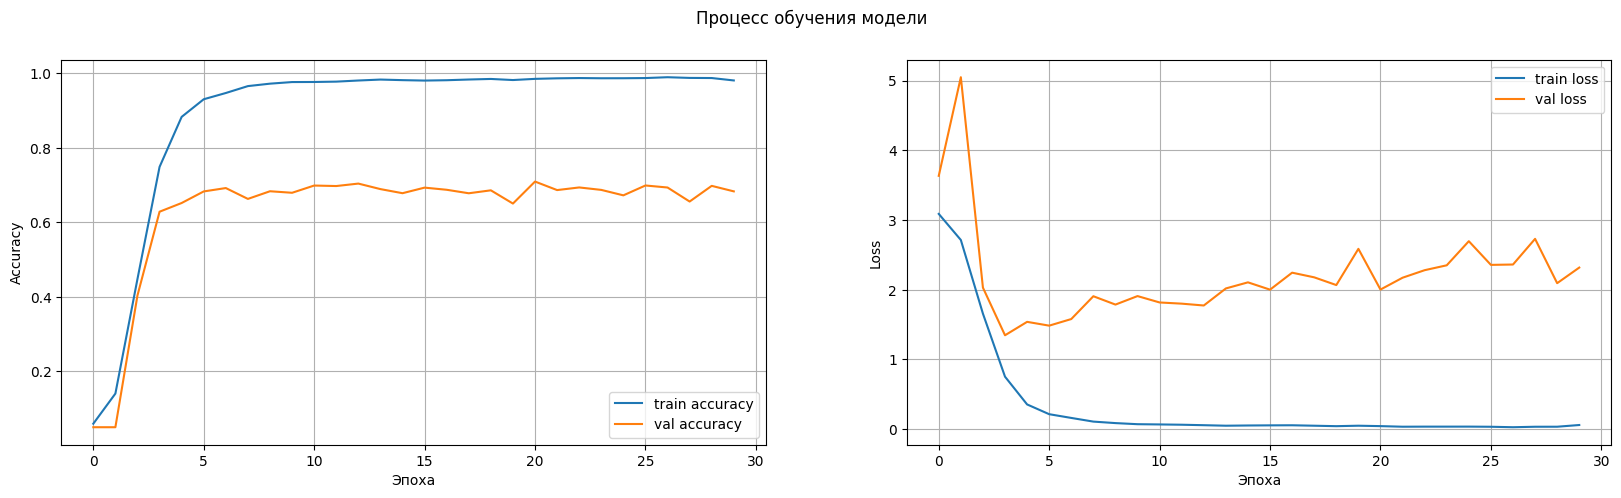


Лучшая val_accuracy: 0.709
Финальная val_accuracy: 0.683


In [ ]:
# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Процесс обучения модели')
ax1.plot(history.history['accuracy'],     label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='val accuracy')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'],     label='train loss')
ax2.plot(history.history['val_loss'], label='val loss')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True)
plt.show()

print(f'\nЛучшая val_accuracy: {max(history.history["val_accuracy"]):.3f}')
print(f'Финальная val_accuracy: {history.history["val_accuracy"][-1]:.3f}')

## 4. Оценка качества

190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


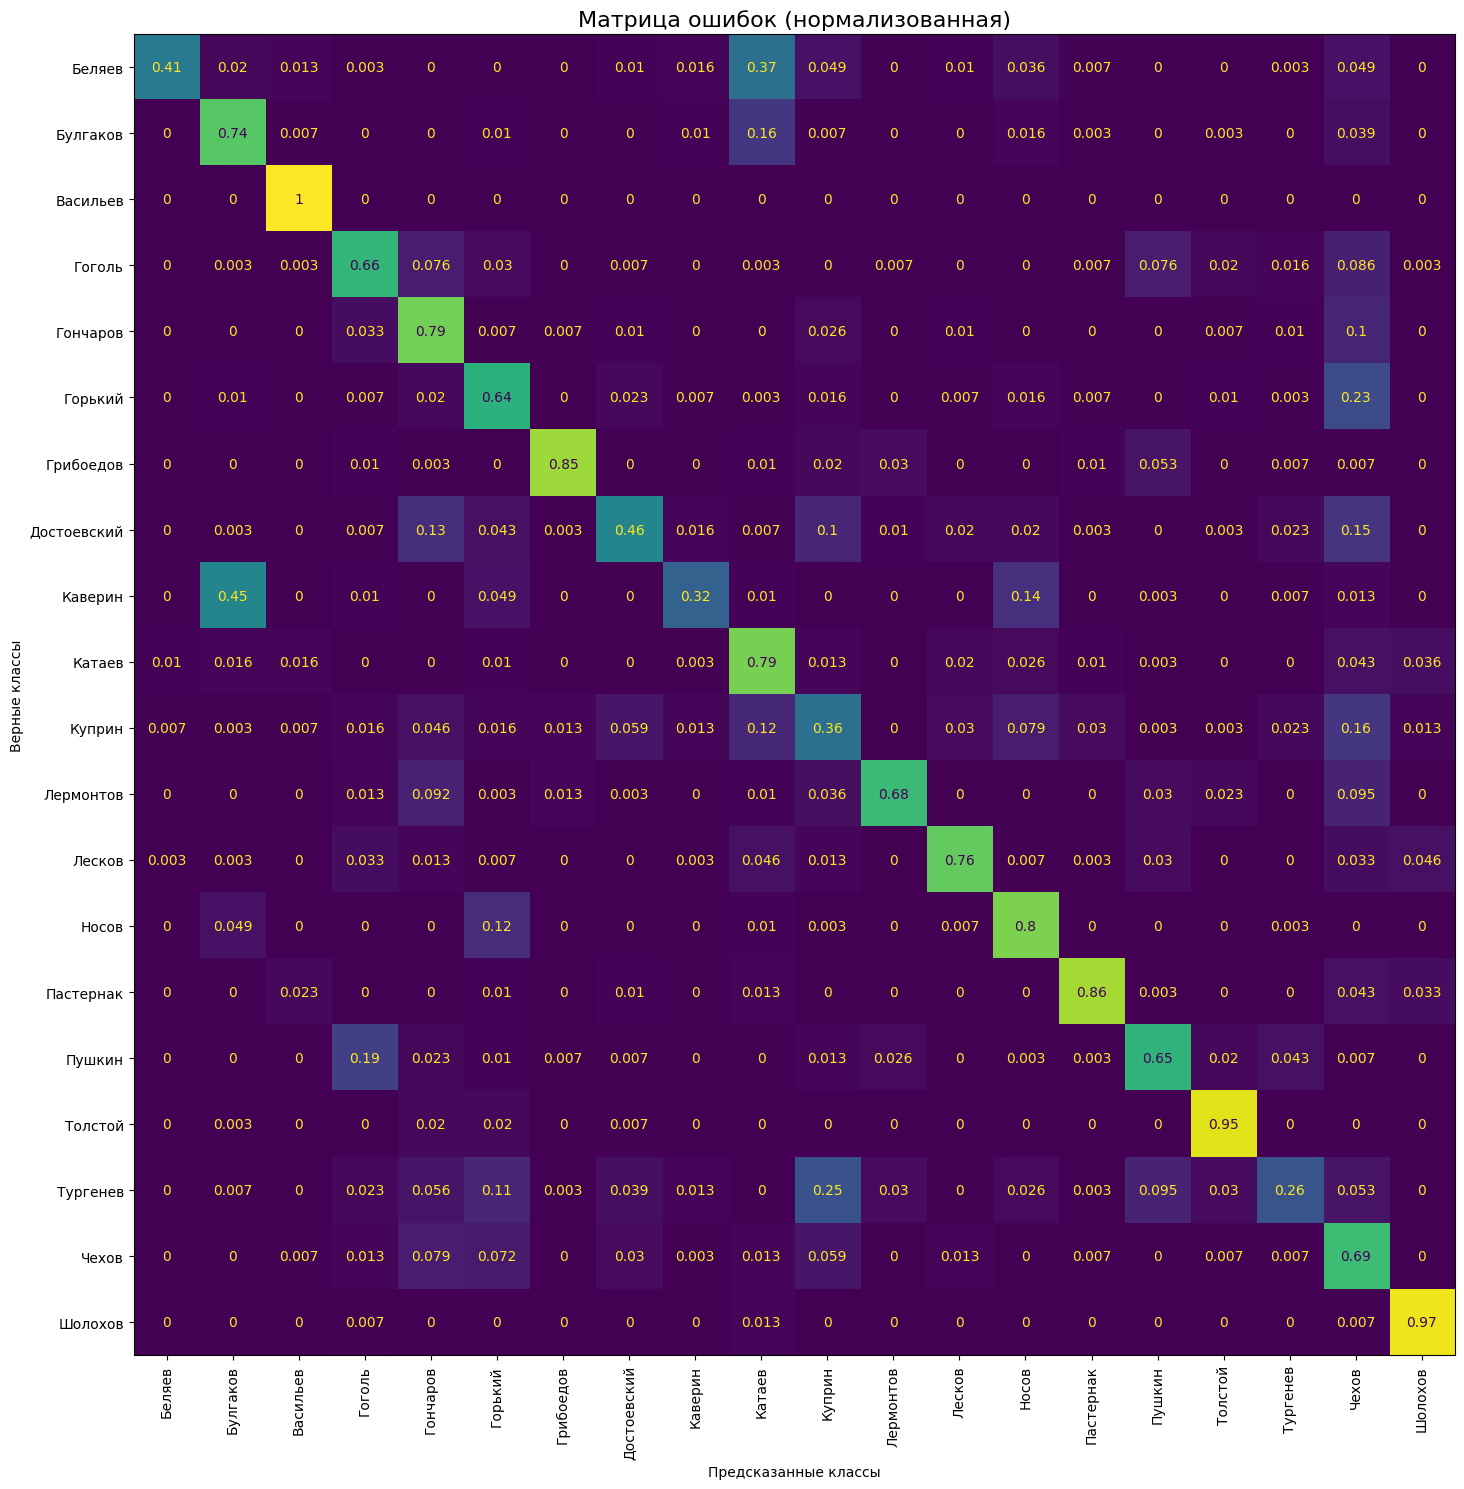

In [ ]:
# Матрица ошибок
y_pred = model.predict(x_test)
cm = confusion_matrix(np.argmax(y_test, axis=1),
                      np.argmax(y_pred, axis=1),
                      normalize='true')
cm = np.around(cm, 3)

fig, ax = plt.subplots(figsize=(15, 15))
ax.set_title('Матрица ошибок (нормализованная)', fontsize=16)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax, xticks_rotation='vertical')
plt.gca().images[-1].colorbar.remove()
plt.xlabel('Предсказанные классы'); plt.ylabel('Верные классы')
plt.tight_layout()
plt.show()

In [ ]:
# Текстовый отчёт
correct_count = 0
print('Результаты распознавания по классам:')
for cls in range(CLASS_COUNT):
    cls_pred = np.argmax(cm[cls])
    is_correct = (cls_pred == cls)
    if is_correct:
        correct_count += 1
    msg = 'ВЕРНО :-)' if is_correct else 'НЕВЕРНО :-('
    print('Класс: {:<25} {:3.0f}% → {:<25} - {}'.format(
        CLASS_LIST[cls],
        100. * cm[cls, cls_pred],
        CLASS_LIST[cls_pred],
        msg))

print('-' * 90)
print(f'Средняя точность распознавания: {100. * cm.diagonal().mean():.1f}%')
print(f'Правильно распознано классов: {correct_count} из {CLASS_COUNT}')

Результаты распознавания по классам:
Класс: Беляев                     41% → Беляев                    - ВЕРНО :-)
Класс: Булгаков                   74% → Булгаков                  - ВЕРНО :-)
Класс: Васильев                  100% → Васильев                  - ВЕРНО :-)
Класс: Гоголь                     66% → Гоголь                    - ВЕРНО :-)
Класс: Гончаров                   79% → Гончаров                  - ВЕРНО :-)
Класс: Горький                    64% → Горький                   - ВЕРНО :-)
Класс: Грибоедов                  85% → Грибоедов                 - ВЕРНО :-)
Класс: Достоевский                46% → Достоевский               - ВЕРНО :-)
Класс: Каверин                    45% → Булгаков                  - НЕВЕРНО :-(
Класс: Катаев                     79% → Катаев                    - ВЕРНО :-)
Класс: Куприн                     36% → Куприн                    - ВЕРНО :-)
Класс: Лермонтов                  68% → Лермонтов                 - ВЕРНО :-)
Класс: Лесков            

## 5.Даём сети предсказать автора своего сочинения.
Можно вставить любой текст в переменную `my_text`.

Чтобы предсказание было устойчивым, **разбиваем текст на несколько окон** того же размера, что и при обучении, и **усредняем** распределение вероятностей.

In [ ]:
# Поместите сюда свой текст (или просто запустите как есть — тогда возьмётся фрагмент из архива)
my_text = """
Одни люди ищут смысл в работе и стремятся достичь профессиональных высот.
Другие же, наоборот, всецело посвящают себя семье и детям.
Творческие личности нередко бывают одержимы идеей создания великого шедевра искусства,
отдавая этому все свои силы. Есть в мире и абсолютные прагматики,
для которых важным становится обретение определённых материальных благ.
""".strip()

# Если хочется проверить на тексте из архива — подставьте кусочек text_test:
# my_text = text_test[5][:3000]   # например, фрагмент из 5-го класса

print(f'Длина моего сочинения: {len(my_text)} символов, {len(my_text.split())} слов')
print(f'Начало текста: {my_text[:200]}...')

Длина моего сочинения: 357 символов, 49 слов
Начало текста: Одни люди ищут смысл в работе и стремятся достичь профессиональных высот.
Другие же, наоборот, всецело посвящают себя семье и детям.
Творческие личности нередко бывают одержимы идеей создания великого...


In [ ]:
def predict_author(text, model, tokenizer, class_list, win_size=WIN_SIZE):
    """Предсказание автора с усреднением по окнам."""
    # Токенизация
    seq = tokenizer.texts_to_sequences([text])[0]
    if len(seq) < 1:
        print('Текст слишком короткий после токенизации.')
        return

    # Если текст короче одного окна — дополняем повторами
    if len(seq) < win_size:
        repeats = (win_size // len(seq)) + 1
        seq = (seq * repeats)[:win_size]
        windows = [seq]
    else:
        # Разбиваем на окна с шагом win_size//4 для более устойчивого предсказания
        hop = max(1, win_size // 4)
        windows = [seq[i:i + win_size] for i in range(0, len(seq) - win_size + 1, hop)]

    x = np.array(windows)
    print(f'Окон для анализа: {len(windows)}')

    # Получаем вероятности
    probs = model.predict(x, verbose=0)
    avg_probs = probs.mean(axis=0)

    # Топ-5 авторов
    top5 = np.argsort(avg_probs)[::-1][:5]

    print('\nТоп-5 наиболее вероятных авторов вашего сочинения:')
    for i, idx in enumerate(top5, 1):
        print(f'{i}. {class_list[idx]:<25} {100*avg_probs[idx]:5.1f}%')

    print(f'\nСеть считает, что это — {class_list[top5[0]]}!')

    # Барплот
    fig, ax = plt.subplots(figsize=(14, 6))
    sorted_idx = np.argsort(avg_probs)[::-1]
    ax.bar(range(len(class_list)),
           [avg_probs[i] for i in sorted_idx],
           color=['#d62728' if i == 0 else '#1f77b4' for i in range(len(class_list))])
    ax.set_xticks(range(len(class_list)))
    ax.set_xticklabels([class_list[i] for i in sorted_idx], rotation=45, ha='right')
    ax.set_ylabel('Вероятность')
    ax.set_title('Распределение вероятностей по авторам')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return avg_probs

Окон для анализа: 1

Топ-5 наиболее вероятных авторов вашего сочинения:
1. Носов                      98.2%
2. Булгаков                    1.7%
3. Горький                     0.1%
4. Катаев                      0.0%
5. Тургенев                    0.0%

Сеть считает, что это — Носов!


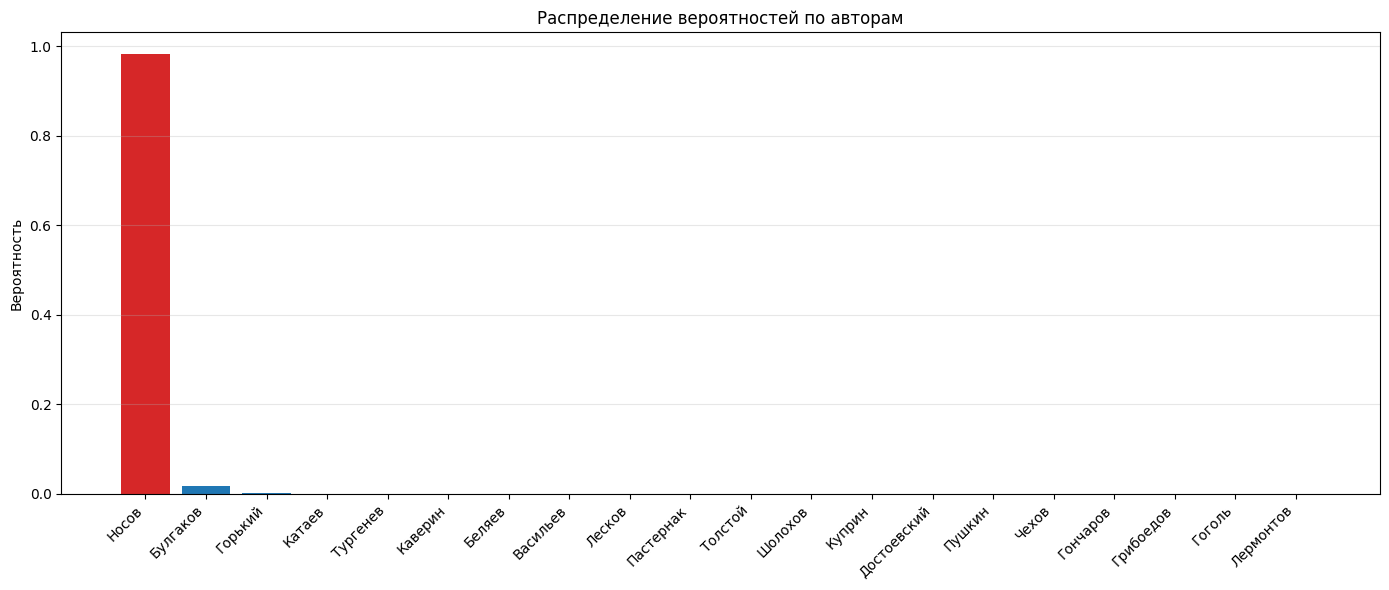

In [ ]:
# Запускаем предсказание
_ = predict_author(my_text, model, tokenizer, CLASS_LIST)

## 6. Бонус: попросим сеть угадать «правильно» — текст из архива

Чтобы убедиться, что сеть в принципе хорошо распознаёт стиль, дадим ей фрагменты из тестовой выборки разных авторов.


 Реальный автор: Булгаков
Окон для анализа: 2

Топ-5 наиболее вероятных авторов вашего сочинения:
1. Катаев                     86.3%
2. Чехов                       8.3%
3. Шолохов                     3.7%
4. Булгаков                    0.7%
5. Пастернак                   0.4%

Сеть считает, что это — Катаев!


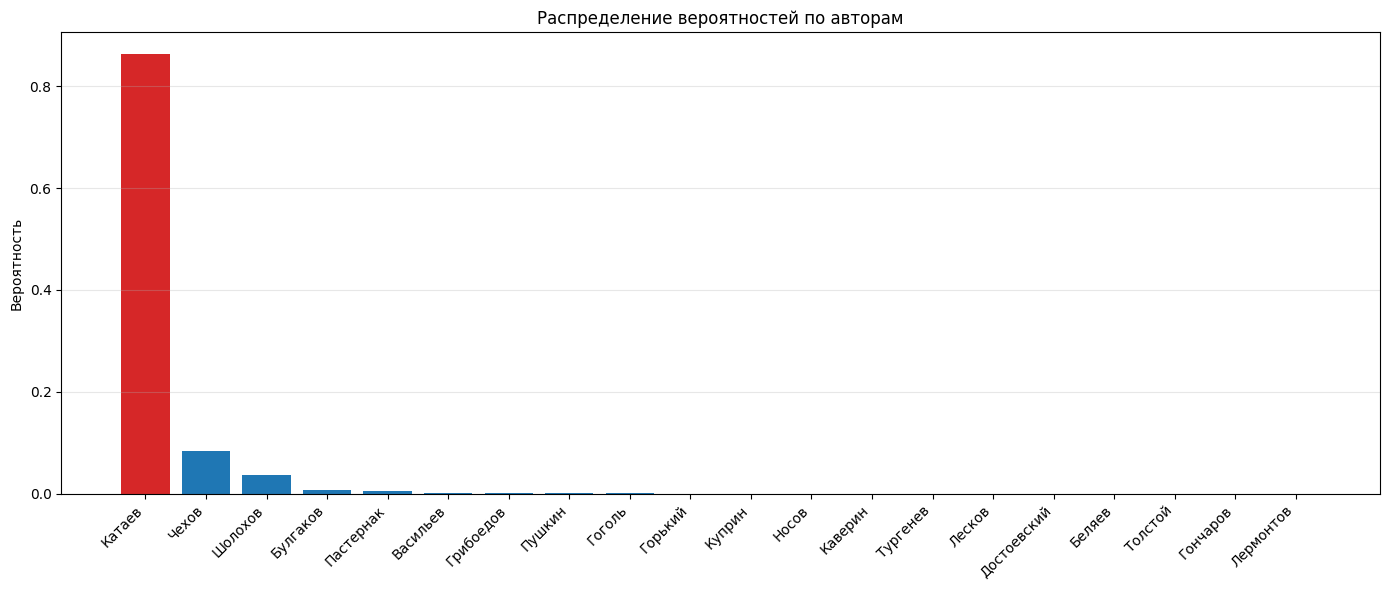


 Реальный автор: Тургенев
Окон для анализа: 3

Топ-5 наиболее вероятных авторов вашего сочинения:
1. Тургенев                  100.0%
2. Носов                       0.0%
3. Каверин                     0.0%
4. Толстой                     0.0%
5. Куприн                      0.0%

Сеть считает, что это — Тургенев!


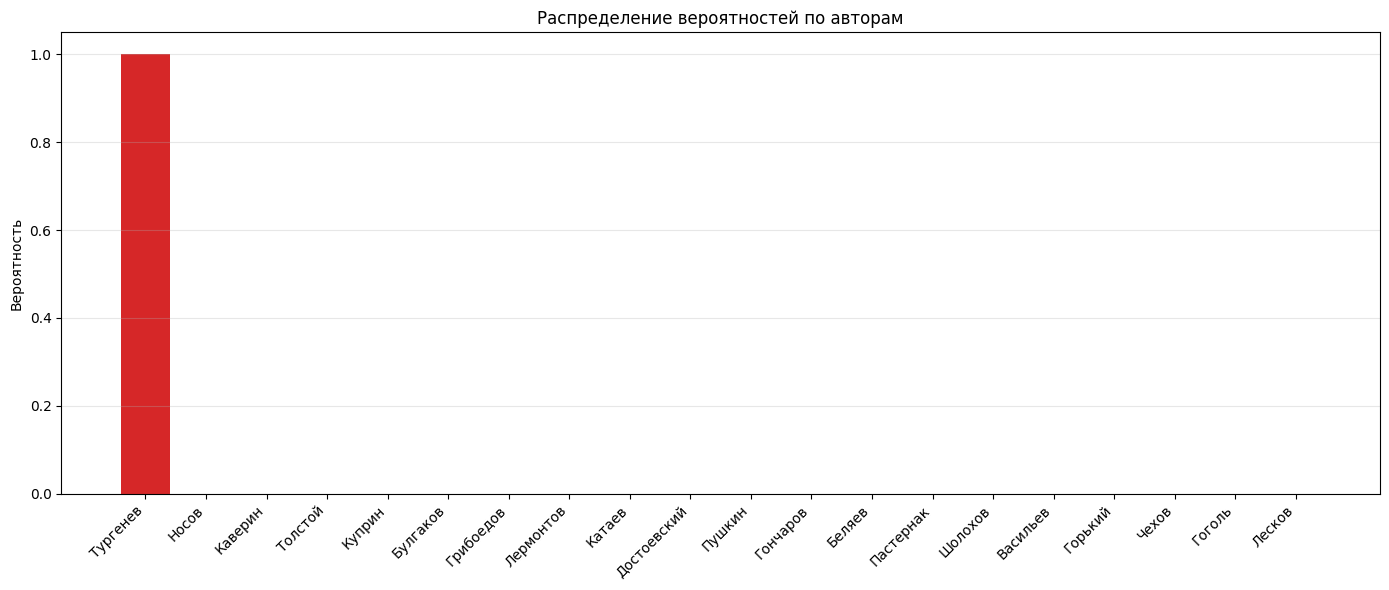


 Реальный автор: Васильев
Окон для анализа: 3

Топ-5 наиболее вероятных авторов вашего сочинения:
1. Васильев                  100.0%
2. Пастернак                   0.0%
3. Булгаков                    0.0%
4. Шолохов                     0.0%
5. Горький                     0.0%

Сеть считает, что это — Васильев!


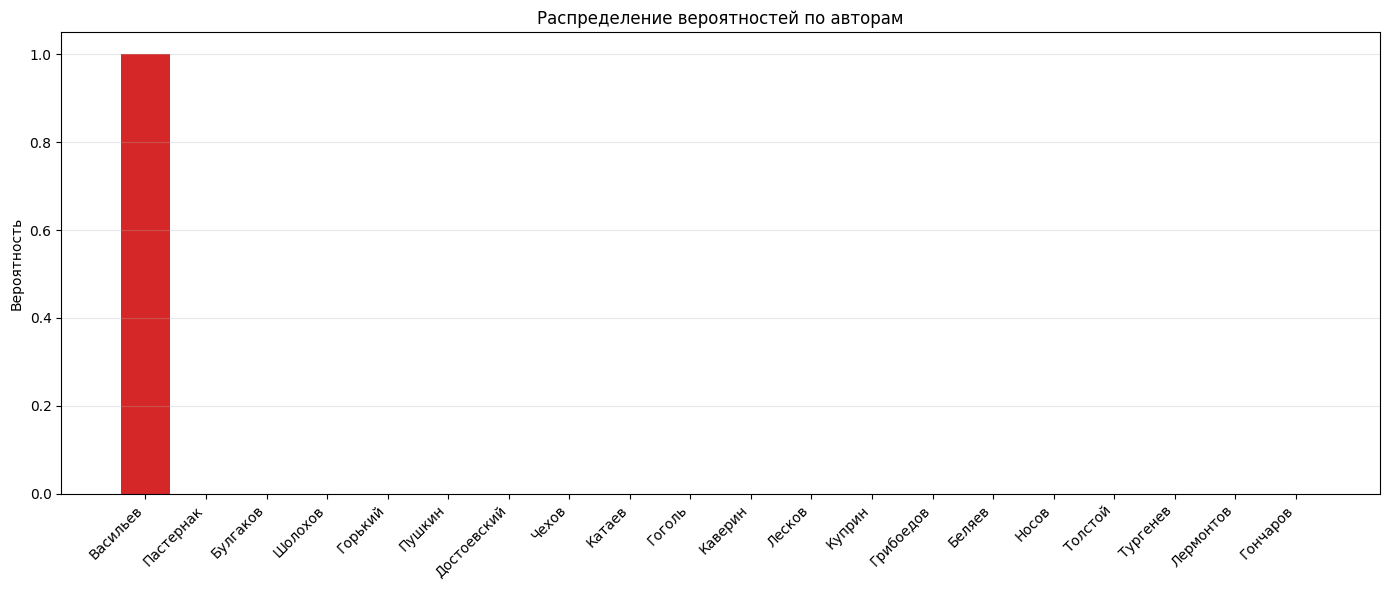

In [ ]:
# Возьмём по фрагменту из 3 случайных классов и проверим
np.random.seed(7)
sample_classes = np.random.choice(CLASS_COUNT, size=min(3, CLASS_COUNT), replace=False)

for cls in sample_classes:
    text = text_test[cls][:5000]   # первые 5000 символов
    if len(text) < 100:
        continue
    print(f'\n Реальный автор: {CLASS_LIST[cls]}')
    _ = predict_author(text, model, tokenizer, CLASS_LIST)